# Random Forest Regression

## Importing the libraries

In [130]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.pyplot import annotate
from sklearn.feature_extraction import grid_to_graph
from tensorflow.python.ops.gen_experimental_dataset_ops import data_service_dataset

from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [131]:
dataset = pd.read_csv('/MachineLearning/Airline_Delay_Cause.csv')


In [132]:
dataset

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
171661,2013,8,YV,Mesa Airlines Inc.,TRI,"Bristol/Johnson City/Kingsport, TN: Tri Cities",7.0,1.0,0.78,0.00,...,0.0,0.00,0.0,0.0,23.0,18.0,0.0,5.0,0.0,0.0
171662,2013,8,YV,Mesa Airlines Inc.,YUM,"Yuma, AZ: Yuma MCAS/Yuma International",2.0,1.0,0.00,0.00,...,0.0,1.00,0.0,0.0,17.0,0.0,0.0,0.0,0.0,17.0
171663,2013,8,YV,Mesa Airlines Inc.,SLC,"Salt Lake City, UT: Salt Lake City International",2.0,0.0,0.00,0.00,...,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
171664,2013,8,DL,Delta Air Lines Inc.,SBN,"South Bend, IN: South Bend International",1.0,1.0,1.00,0.00,...,0.0,0.00,0.0,0.0,18.0,18.0,0.0,0.0,0.0,0.0


In [133]:
dataset.iloc[:,7].values

array([13., 10., 10., ...,  0.,  1.,  0.])

In [134]:
X = dataset.iloc[:, :7].values
y = dataset.iloc[:, 7].values

In [135]:
y

array([13., 10., 10., ...,  0.,  1.,  0.])

In [136]:
numerical_col=['year','month','arr_flights','carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct','arr_cancelled','arr_diverted','arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay','arr_del15']
categorical_col=['carrier','carrier_name','airport','airport_name']

### Data Preprocessing

In [137]:
dataset.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

### filling the Null values


In [138]:
dataset[numerical_col]=dataset[numerical_col].fillna(dataset[numerical_col].median())

In [139]:
dataset.isnull().sum()

year                   0
month                  0
carrier                0
carrier_name           0
airport                0
airport_name           0
arr_flights            0
arr_del15              0
carrier_ct             0
weather_ct             0
nas_ct                 0
security_ct            0
late_aircraft_ct       0
arr_cancelled          0
arr_diverted           0
arr_delay              0
carrier_delay          0
weather_delay          0
nas_delay              0
security_delay         0
late_aircraft_delay    0
dtype: int64

### Encoding the Categorical Variable


In [140]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder(handle_unknown='ignore')


In [141]:
preprocessor=ColumnTransformer(transformers=[('encorder',OneHotEncoder(),categorical_col)])

In [142]:
transformed_data=preprocessor.fit_transform(dataset)

In [143]:
print(transformed_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 686664 stored elements and shape (171666, 858)>
  Coords	Values
  (0, 0)	1.0
  (0, 27)	1.0
  (0, 44)	1.0
  (0, 449)	1.0
  (1, 0)	1.0
  (1, 27)	1.0
  (1, 48)	1.0
  (1, 445)	1.0
  (2, 0)	1.0
  (2, 27)	1.0
  (2, 55)	1.0
  (2, 448)	1.0
  (3, 0)	1.0
  (3, 27)	1.0
  (3, 56)	1.0
  (3, 460)	1.0
  (4, 0)	1.0
  (4, 27)	1.0
  (4, 58)	1.0
  (4, 446)	1.0
  (5, 0)	1.0
  (5, 27)	1.0
  (5, 67)	1.0
  (5, 458)	1.0
  (6, 0)	1.0
  :	:
  (171659, 620)	1.0
  (171660, 19)	1.0
  (171660, 35)	1.0
  (171660, 71)	1.0
  (171660, 455)	1.0
  (171661, 19)	1.0
  (171661, 35)	1.0
  (171661, 415)	1.0
  (171661, 485)	1.0
  (171662, 19)	1.0
  (171662, 35)	1.0
  (171662, 438)	1.0
  (171662, 857)	1.0
  (171663, 19)	1.0
  (171663, 35)	1.0
  (171663, 391)	1.0
  (171663, 775)	1.0
  (171664, 4)	1.0
  (171664, 26)	1.0
  (171664, 373)	1.0
  (171664, 800)	1.0
  (171665, 6)	1.0
  (171665, 31)	1.0
  (171665, 305)	1.0
  (171665, 697)	1.0


In [144]:
dataset_heatmap=dataset.drop(columns=['carrier','carrier_name','airport','airport_name'],axis=1)

<Axes: >

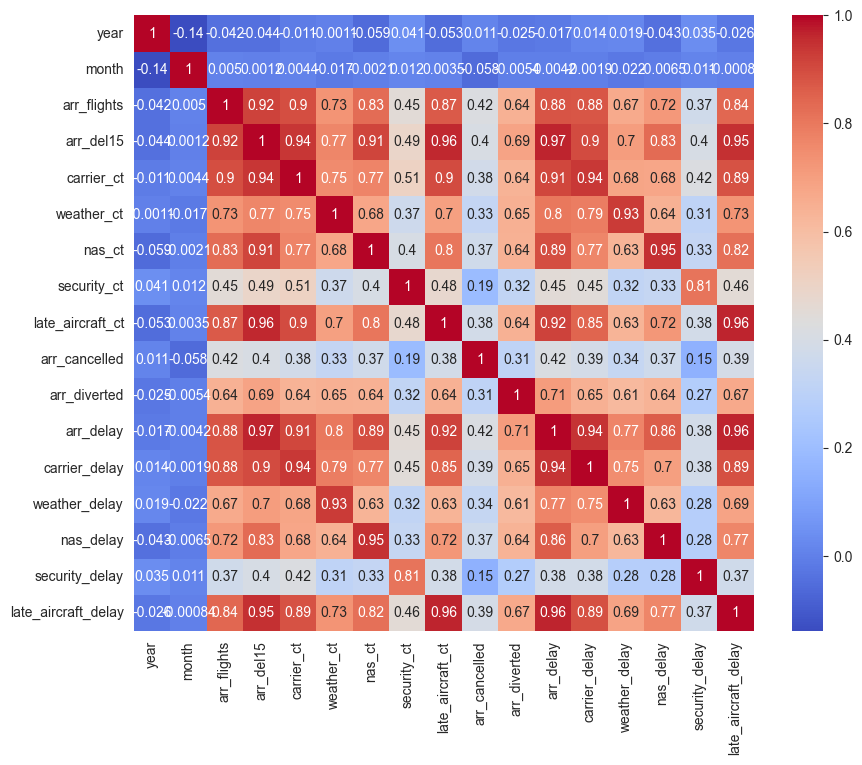

In [145]:
plt.figure(figsize=(10,8))
sns.heatmap(dataset_heatmap.corr(),cmap="coolwarm",annot=True)

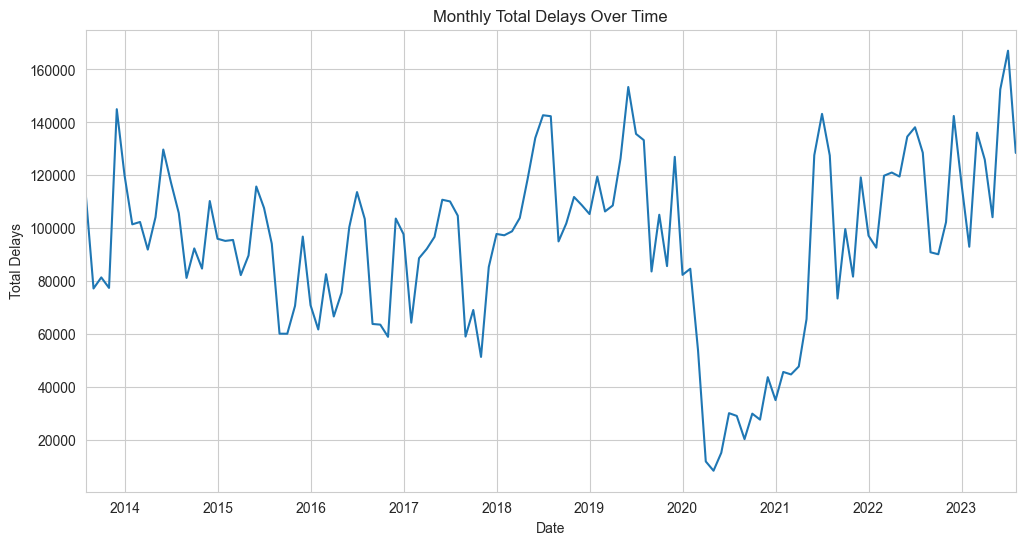

In [146]:
dataset['date'] = pd.to_datetime(dataset[['year', 'month']].assign(DAY=1))
monthly_delays = dataset.groupby('date')['arr_del15'].sum()
plt.figure(figsize=(12, 6))
monthly_delays.plot(kind='line')
plt.title('Monthly Total Delays Over Time')
plt.xlabel('Date')
plt.ylabel('Total Delays')
plt.show()


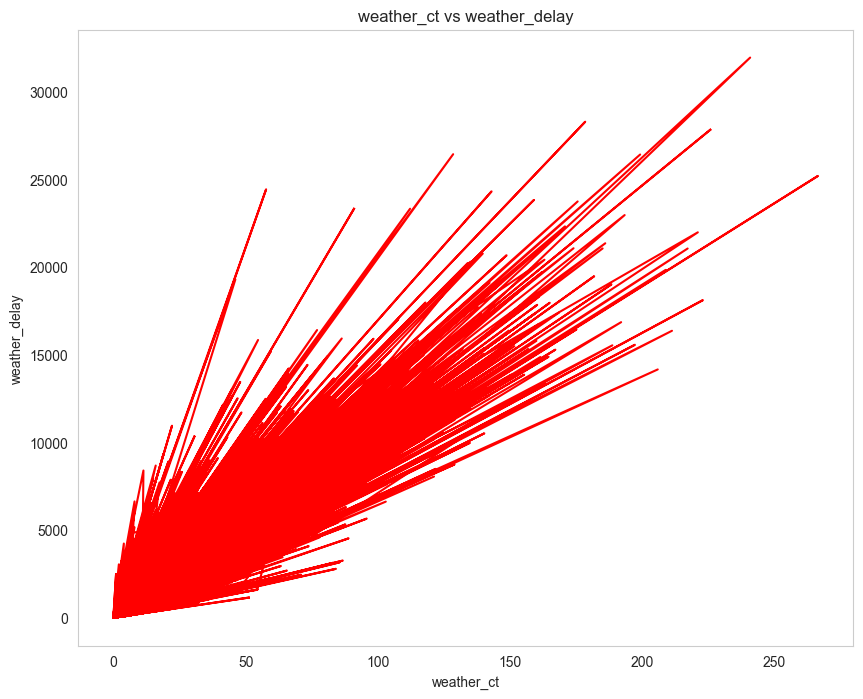

In [147]:
y=dataset['year']
plt.figure(figsize=(10,8))
plt.plot(dataset['weather_ct'],dataset['weather_delay'],color='red')
plt.title('weather_ct vs weather_delay')
plt.grid(False)
plt.xlabel('weather_ct')
plt.ylabel('weather_delay')
plt.show()

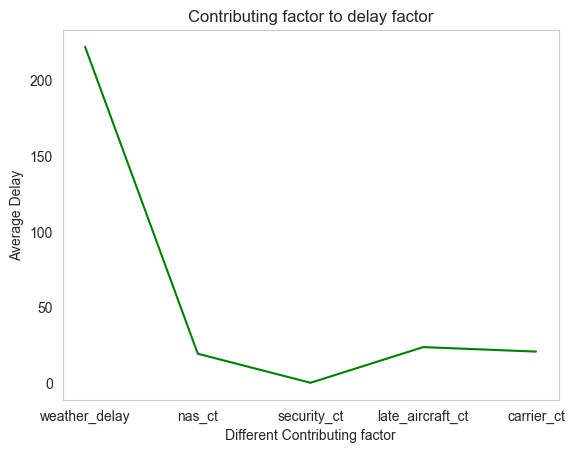

In [148]:
delay_factor=dataset[['weather_delay','nas_ct','security_ct','late_aircraft_ct','carrier_ct']].mean()
delay_factor.plot(kind='line',color='green')
plt.title('Contributing factor to delay factor')
plt.xlabel('Different Contributing factor')
plt.ylabel('Average Delay')
plt.grid(False)
plt.show()

In [149]:
print(transformed_data)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 686664 stored elements and shape (171666, 858)>
  Coords	Values
  (0, 0)	1.0
  (0, 27)	1.0
  (0, 44)	1.0
  (0, 449)	1.0
  (1, 0)	1.0
  (1, 27)	1.0
  (1, 48)	1.0
  (1, 445)	1.0
  (2, 0)	1.0
  (2, 27)	1.0
  (2, 55)	1.0
  (2, 448)	1.0
  (3, 0)	1.0
  (3, 27)	1.0
  (3, 56)	1.0
  (3, 460)	1.0
  (4, 0)	1.0
  (4, 27)	1.0
  (4, 58)	1.0
  (4, 446)	1.0
  (5, 0)	1.0
  (5, 27)	1.0
  (5, 67)	1.0
  (5, 458)	1.0
  (6, 0)	1.0
  :	:
  (171659, 620)	1.0
  (171660, 19)	1.0
  (171660, 35)	1.0
  (171660, 71)	1.0
  (171660, 455)	1.0
  (171661, 19)	1.0
  (171661, 35)	1.0
  (171661, 415)	1.0
  (171661, 485)	1.0
  (171662, 19)	1.0
  (171662, 35)	1.0
  (171662, 438)	1.0
  (171662, 857)	1.0
  (171663, 19)	1.0
  (171663, 35)	1.0
  (171663, 391)	1.0
  (171663, 775)	1.0
  (171664, 4)	1.0
  (171664, 26)	1.0
  (171664, 373)	1.0
  (171664, 800)	1.0
  (171665, 6)	1.0
  (171665, 31)	1.0
  (171665, 305)	1.0
  (171665, 697)	1.0


In [150]:
categorical_columns=['carrier','carrier_name','airport','airport_name']
dataset = pd.get_dummies(dataset, columns=categorical_columns, dtype=int)
dataset.isnull().sum()

year                                                              0
month                                                             0
arr_flights                                                       0
arr_del15                                                         0
carrier_ct                                                        0
                                                                 ..
airport_name_Wrangell, AK: Wrangell Airport                       0
airport_name_Yakima, WA: Yakima Air Terminal/McAllister Field     0
airport_name_Yakutat, AK: Yakutat Airport                         0
airport_name_Youngstown/Warren, OH: Youngstown-Warren Regional    0
airport_name_Yuma, AZ: Yuma MCAS/Yuma International               0
Length: 876, dtype: int64

## Splitting the dataset into the Training set and Test set

In [151]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Training the Random Forest Regression model on the whole dataset

In [152]:
columns_to_drop = ['year', 'month', 'arr_del15']
df_features = dataset.drop(columns=columns_to_drop)

X = df_features
datetime_columns = X.select_dtypes(include=['datetime64[ns]']).columns
X = X.drop(columns=datetime_columns)

X = X.astype(float)
y = dataset['arr_del15'] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
from sklearn.ensemble import RandomForestRegressor
regressor = RandomForestRegressor(n_estimators = 10, random_state = 0)
regressor.fit(X_train, y_train)

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [160]:
y_pred_for=regressor.predict(X_test)

[ 6.1 36.2 68.8 ...  6.2  3.  27. ]


4739       6.0
146047    33.0
25700     68.0
123710    14.0
39508      2.0
          ... 
143257    51.0
165697    51.0
4731       6.0
79541      3.0
169686    27.0
Name: arr_del15, Length: 34334, dtype: float64


## Predicting the Test set results

## Evaluating the Model Performance

In [155]:
from sklearn.metrics import r2_score

In [156]:
from sklearn.metrics import mean_squared_error,confusion_matrix,classification_report,accuracy_score

In [174]:
# XGBRegressor Model
xgb_model = XGBRegressor(n_estimators=1000, random_state=42)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)


In [175]:
r2_sc=r2_score(y_test, y_pred_xgb)
rmse=mean_squared_error(y_test, y_pred_xgb)
print("\n  The R2 score for this model is:",r2_sc)
print("\n  The RMSE for this model is:",rmse)


  The R2 score for this model is: 0.9906169868073001

  The RMSE for this model is: 294.3925991976954


In [176]:
mean_error=mean_squared_error(y_test, y_pred_xgb)
print("\n  The MAE for this model is:",mean_error)



  The MAE for this model is: 294.3925991976954
